#  House Price Prediction Using Machine Learning
### Week 1 Task - Data Science Intern

---
##  Project Overview
**Objective:** Train a regression model to predict house prices using the California Housing Dataset.

**Challenges Addressed:**
-  Feature scaling and encoding categorical data
-  Train/test split and evaluate model using RMSE and R²
-  Visualize model performance and key features

**Tech Stack:** `Python`, `Pandas`, `NumPy`, `Scikit-learn`, `Matplotlib`, `Seaborn`

In [1]:
# ==========================================================================
# IMPORTS
# ==========================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
import joblib
import os

# ==========================================================================
# CONFIGURATION
# ==========================================================================
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(" All libraries imported successfully!")

 All libraries imported successfully!


---
##  Step 1: Load Data

In [2]:
# ==========================================================================
# STEP 1: DATA LOADING
# ==========================================================================
dataset_path = os.path.join('data', 'california_housing.csv')
df = pd.read_csv(dataset_path)

print('=' * 60)
print('  CALIFORNIA HOUSING DATASET LOADED FROM LOCAL CSV')
print('=' * 60)
print(f' Dataset Shape: {df.shape}')
print(f' Number of Features: {df.shape[1] - 1}')
print(f' Number of Samples: {df.shape[0]:,}')

df.head()

  CALIFORNIA HOUSING DATASET LOADED
 Dataset Shape: (20640, 9)
 Number of Features: 8
 Number of Samples: 20,640


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


###  Feature Descriptions

| Feature | Description |
|---------|-------------|
| **MedInc** | Median Income (in tens of thousands of dollars) |
| **HouseAge** | Median House Age (in years) |
| **AveRooms** | Average Number of Rooms per household |
| **AveBedrms** | Average Number of Bedrooms per household |
| **Population** | Block Group Population |
| **AveOccup** | Average Number of Occupants per household |
| **Latitude** | Block Group Latitude |
| **Longitude** | Block Group Longitude |
| **MedHouseVal** | **TARGET** - Median House Value (in $100,000s) |

> **Note:** California Housing dataset is used instead of Boston Housing (which is deprecated due to ethical concerns in its original feature set).

---
##  Step 2: Exploratory Data Analysis (EDA)

In [3]:
# ==========================================================================
# STEP 2: BASIC DATA INFO
# ==========================================================================
print(" DATASET INFO:")
print("-" * 40)
df.info()

print("\n" + "=" * 60)
print(" STATISTICAL SUMMARY:")
print("-" * 40)
display(df.describe().round(2))

 DATASET INFO:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

 STATISTICAL SUMMARY:
----------------------------------------


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [4]:
# ==========================================================================
# STEP 2.1: MISSING & DUPLICATE VALUES
# ==========================================================================
print(" MISSING VALUES:")
print("-" * 40)
missing = df.isnull().sum()
print(missing)
print(f"\n Total Missing Values: {missing.sum()}")

print("\n" + "=" * 60)
print(" DUPLICATE VALUES:")
print("-" * 40)
duplicates = df.duplicated().sum()
print(f" Duplicate Rows: {duplicates}")

if missing.sum() == 0 and duplicates == 0:
    print("\n Dataset is CLEAN - No missing or duplicate values!")

 MISSING VALUES:
----------------------------------------
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

 Total Missing Values: 0

 DUPLICATE VALUES:
----------------------------------------
 Duplicate Rows: 0

 Dataset is CLEAN - No missing or duplicate values!


---
##  Step 3: Data Visualization

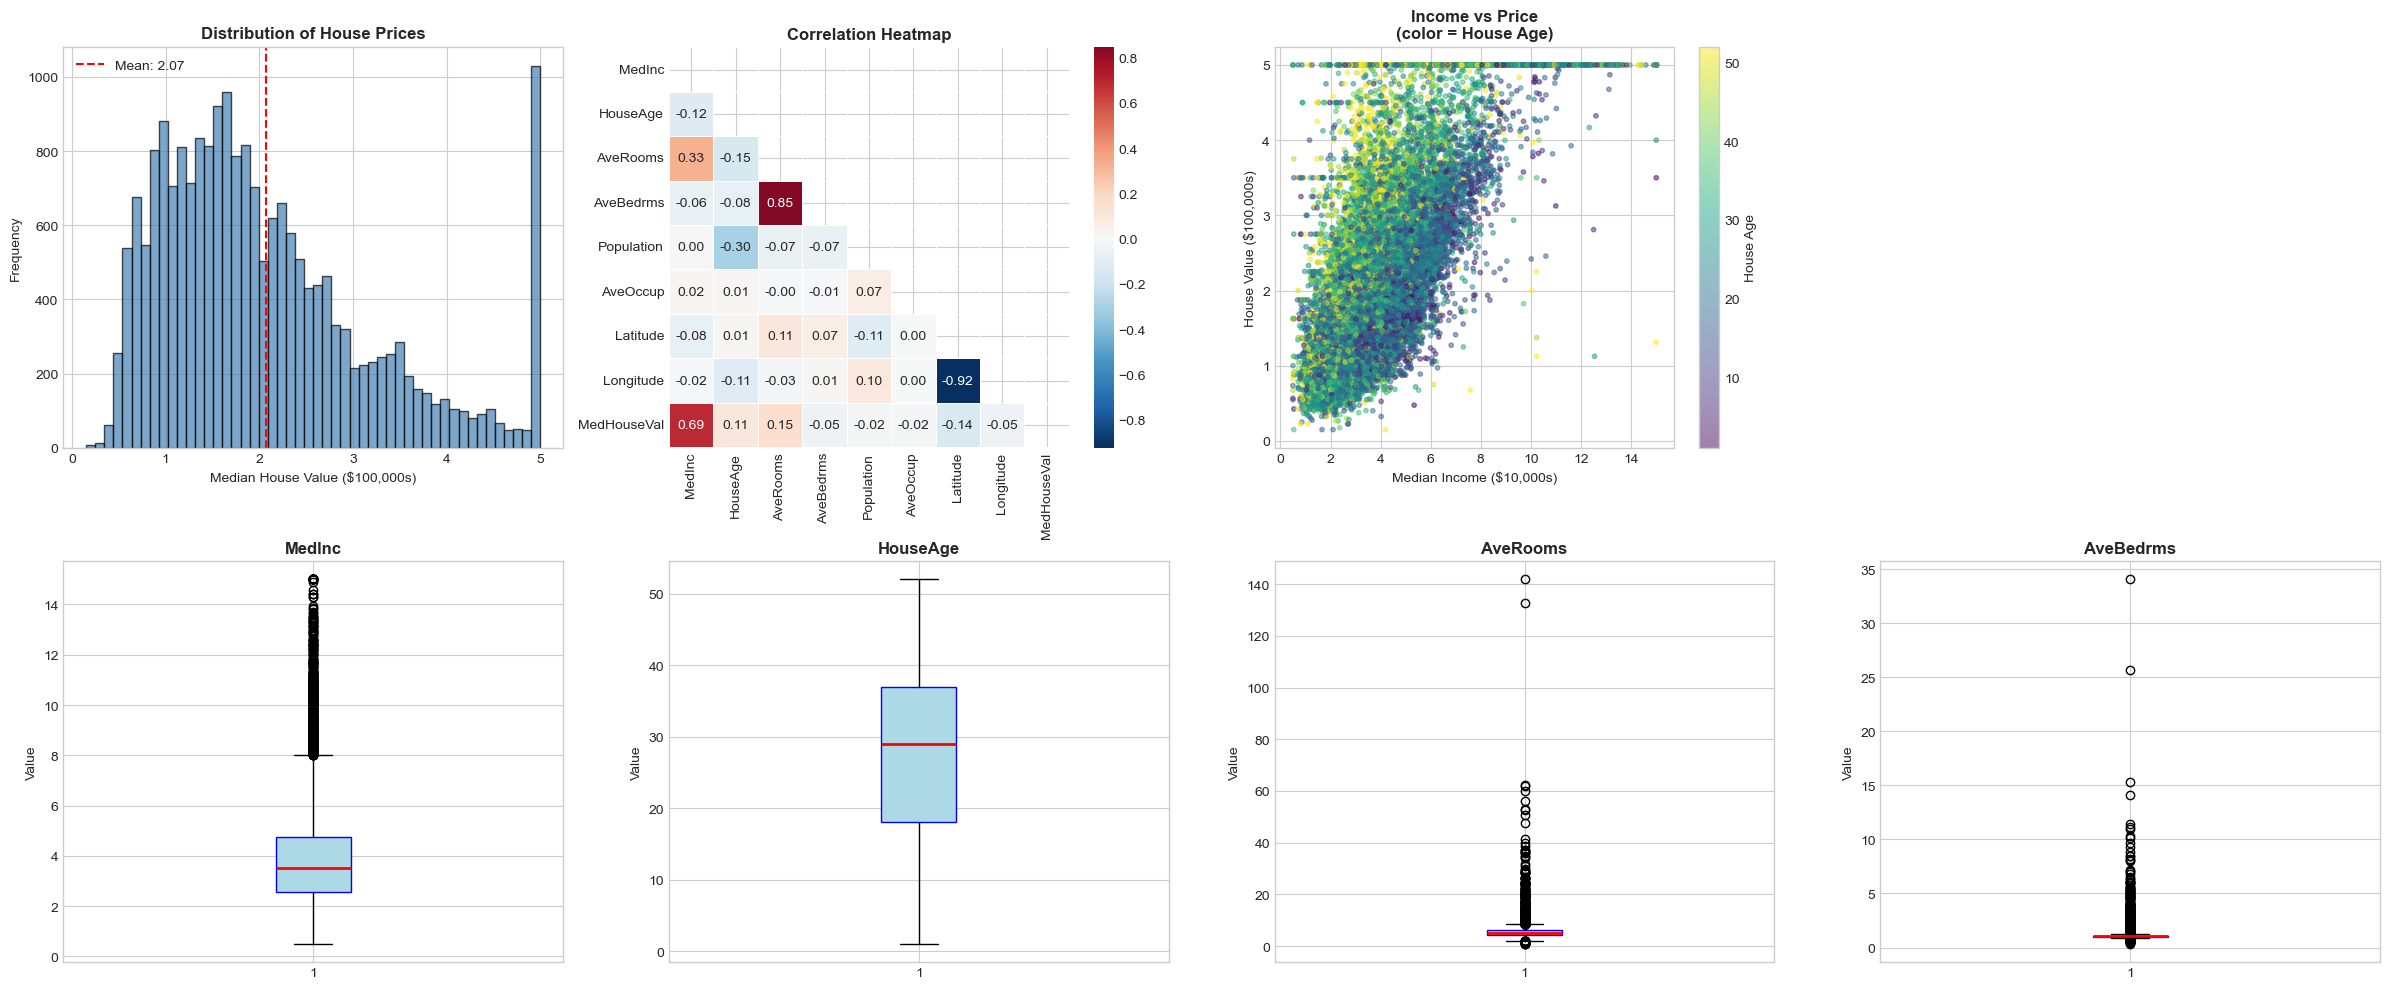

 Saved: 01_eda_overview.png


In [6]:
# ==========================================================================
# STEP 3.1: EDA OVERVIEW
# ==========================================================================
os.makedirs('output/visualizations', exist_ok=True)

# Changed from (2, 3) to (2, 4) to accommodate 4 boxplots in the bottom row
fig, axes = plt.subplots(2, 4, figsize=(24, 10))  # Increased width for 4 columns

# 1. Target Distribution
axes[0, 0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['MedHouseVal'].mean(), color='red', linestyle='--', 
                    label=f'Mean: {df["MedHouseVal"].mean():.2f}')
axes[0, 0].set_xlabel('Median House Value ($100,000s)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of House Prices', fontweight='bold')
axes[0, 0].legend()

# 2. Correlation Heatmap
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, ax=axes[0, 1], 
            square=True, linewidths=0.5)
axes[0, 1].set_title('Correlation Heatmap', fontweight='bold')

# 3. Income vs Price Scatter
scatter = axes[0, 2].scatter(df['MedInc'], df['MedHouseVal'], 
                              c=df['HouseAge'], cmap='viridis', alpha=0.5, s=10)
axes[0, 2].set_xlabel('Median Income ($10,000s)')
axes[0, 2].set_ylabel('House Value ($100,000s)')
axes[0, 2].set_title('Income vs Price\n(color = House Age)', fontweight='bold')
plt.colorbar(scatter, ax=axes[0, 2], label='House Age')

# Hide the unused subplot in the top row
axes[0, 3].axis('off')  # Hide the 4th subplot in the top row

# 4-7. Boxplots for Outlier Detection (now fits in 4 columns)
boxplot_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms']
for idx, feature in enumerate(boxplot_features):
    axes[1, idx].boxplot(df[feature], patch_artist=True,
                          boxprops=dict(facecolor='lightblue', color='blue'),
                          medianprops=dict(color='red', linewidth=2))
    axes[1, idx].set_title(f'{feature}', fontweight='bold')
    axes[1, idx].set_ylabel('Value')

plt.tight_layout()
plt.savefig('output/visualizations/01_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Saved: 01_eda_overview.png")

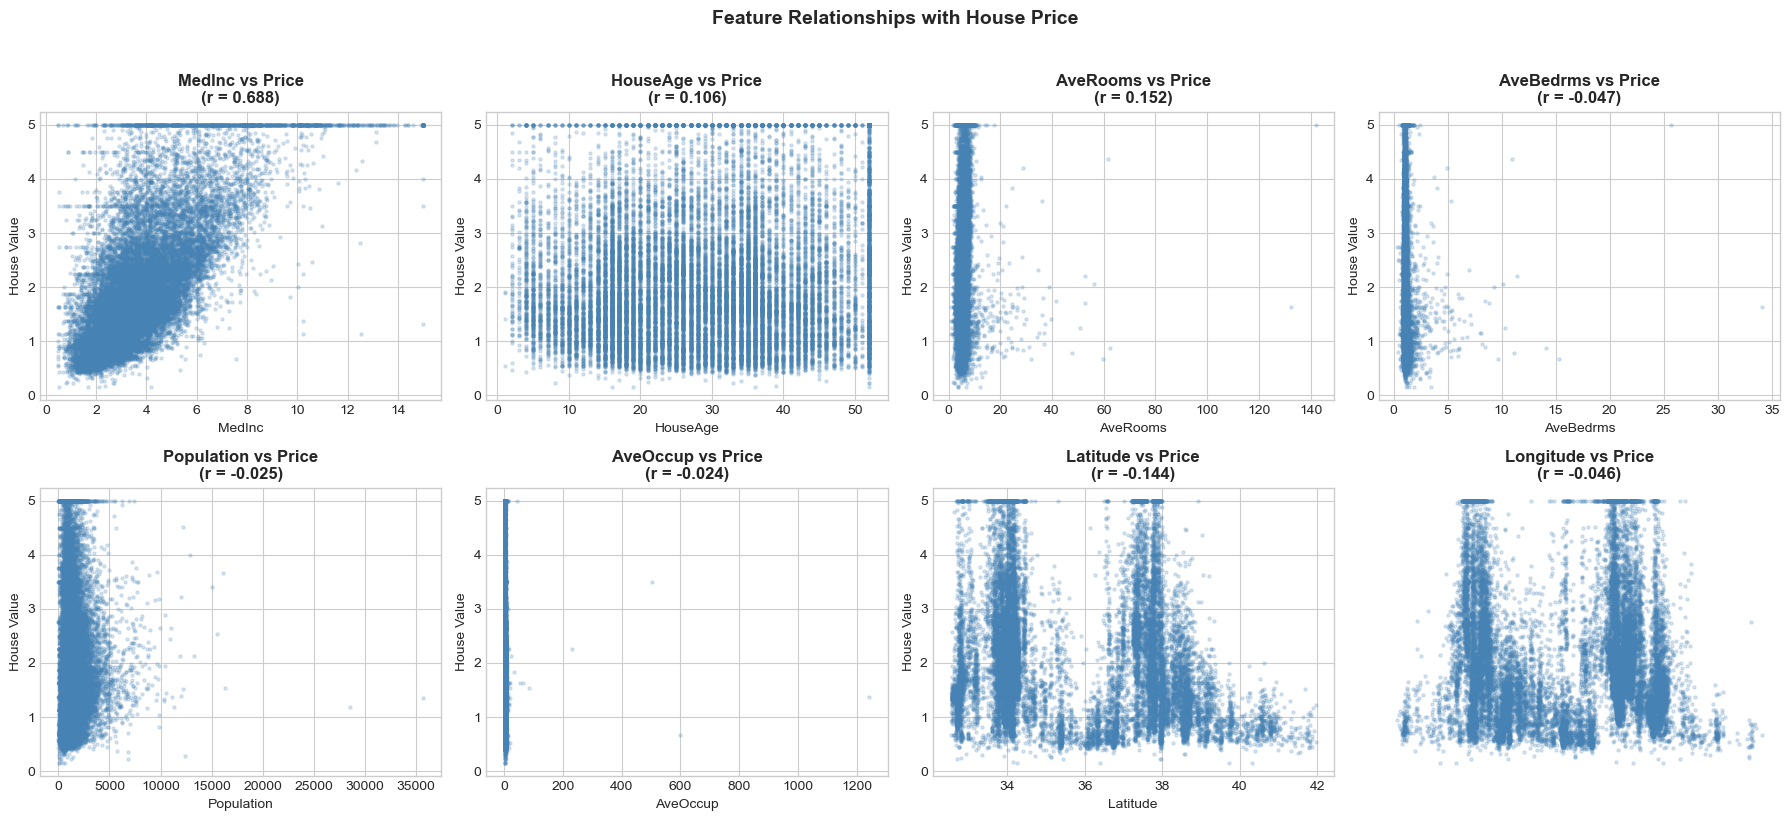

 Saved: 02_feature_relationships.png


In [7]:
# ==========================================================================
# STEP 3.2: FEATURE RELATIONSHIPS
# ==========================================================================
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, feature in enumerate(california.feature_names):
    r = corr_matrix.loc[feature, 'MedHouseVal']
    axes[idx].scatter(df[feature], df['MedHouseVal'], alpha=0.2, s=5, color='steelblue')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('House Value')
    axes[idx].set_title(f'{feature} vs Price\n(r = {r:.3f})', fontweight='bold')

axes[-1].axis('off')
plt.suptitle('Feature Relationships with House Price', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/visualizations/02_feature_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Saved: 02_feature_relationships.png")

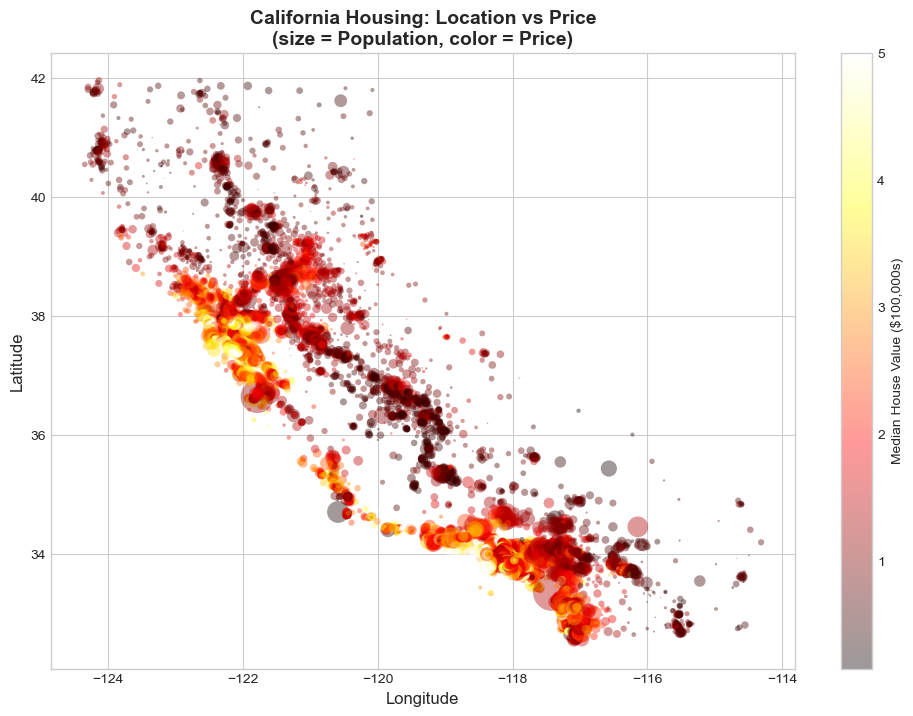

 Saved: 03_geographical_distribution.png

 Key Observation: Coastal areas (especially SF/LA) have higher prices!


In [8]:
# ==========================================================================
# STEP 3.3: GEOGRAPHICAL DISTRIBUTION
# ==========================================================================
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(df['Longitude'], df['Latitude'], 
                     c=df['MedHouseVal'], cmap='hot', 
                     alpha=0.4, s=df['Population']/50, edgecolors='none')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('California Housing: Location vs Price\n(size = Population, color = Price)', 
             fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Median House Value ($100,000s)')
plt.savefig('output/visualizations/03_geographical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Saved: 03_geographical_distribution.png")
print("\n Key Observation: Coastal areas (especially SF/LA) have higher prices!")

---
##  Step 4: Data Preprocessing

In [9]:
# ==========================================================================
# STEP 4: DATA PREPROCESSING
# ==========================================================================
print(" DATA PREPROCESSING")
print("=" * 60)

# 4.1 Handle Outliers using IQR Method
print("\n Step 4.1: Removing Outliers (IQR Method)")
print("-" * 40)

def remove_outliers_iqr(data, columns, threshold=1.5):
    df_clean = data.copy()
    total_removed = 0
    
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - threshold * IQR
        upper = Q3 + threshold * IQR
        
        mask = (df_clean[col] >= lower) & (df_clean[col] <= upper)
        removed = (~mask).sum()
        total_removed += removed
        print(f"  {col}: {removed} outliers removed")
        df_clean = df_clean[mask]
    
    return df_clean, total_removed

outlier_cols = ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']
df_clean, total_outliers = remove_outliers_iqr(df, outlier_cols)

print(f"\n Total Outliers Removed: {total_outliers:,}")
print(f" Dataset Size: {df.shape[0]:,} → {df_clean.shape[0]:,} ({total_outliers/df.shape[0]*100:.1f}% removed)")

# 4.2 Feature-Target Separation
X = df_clean.drop('MedHouseVal', axis=1)
y = df_clean['MedHouseVal']

# 4.3 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"\n Data Split:")
print(f"   Training Set: {X_train.shape[0]:,} samples (80%)")
print(f"   Test Set: {X_test.shape[0]:,} samples (20%)")

# 4.4 Feature Scaling
print(f"\n Step 4.2: Feature Scaling (StandardScaler)")
print("-" * 40)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Show scaling effect
print("\nBefore Scaling (Training Set):")
display(X_train.describe().loc[['mean', 'std']].round(2))

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print("\nAfter Scaling (Training Set):")
display(X_train_scaled_df.describe().loc[['mean', 'std']].round(2))

print("\n Features scaled to mean ≈ 0, std ≈ 1")

 DATA PREPROCESSING

 Step 4.1: Removing Outliers (IQR Method)
----------------------------------------
  AveRooms: 511 outliers removed
  AveBedrms: 1160 outliers removed
  AveOccup: 628 outliers removed
  Population: 1048 outliers removed

 Total Outliers Removed: 3,347
 Dataset Size: 20,640 → 17,293 (16.2% removed)

 Data Split:
   Training Set: 13,834 samples (80%)
   Test Set: 3,459 samples (20%)

 Step 4.2: Feature Scaling (StandardScaler)
----------------------------------------

Before Scaling (Training Set):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
mean,3.89,29.70,5.23,1.05,1260.63,2.84,35.65,-119.63
std,1.80,12.26,1.11,0.07,624.54,0.62,2.12,1.99



After Scaling (Training Set):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
mean,0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0



 Features scaled to mean ≈ 0, std ≈ 1


---
##  Step 5: Model Training

In [10]:
# ==========================================================================
# STEP 5: MODEL TRAINING
# ==========================================================================
print(" MODEL TRAINING")
print("=" * 60)

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso Regression': Lasso(alpha=0.01, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, 
                                           random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                                   learning_rate=0.1, 
                                                   random_state=RANDOM_STATE)
}

# Train and evaluate
results = {}

for name, model in models.items():
    print(f"\n Training {name}...", end=" ")
    
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    
    results[name] = {
        'model': model,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_mae': test_mae,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_test_pred': y_test_pred
    }
    
    print(f" Done!")
    print(f"   Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")
    print(f"   Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")
    print(f"   CV R²: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

 MODEL TRAINING

 Training Linear Regression...  Done!
   Train RMSE: 0.6455 | Test RMSE: 0.6553
   Train R²: 0.6825 | Test R²: 0.6748
   CV R²: 0.6818 (±0.0044)

 Training Ridge Regression...  Done!
   Train RMSE: 0.6455 | Test RMSE: 0.6553
   Train R²: 0.6825 | Test R²: 0.6748
   CV R²: 0.6818 (±0.0044)

 Training Lasso Regression...  Done!
   Train RMSE: 0.6482 | Test RMSE: 0.6566
   Train R²: 0.6799 | Test R²: 0.6735
   CV R²: 0.6793 (±0.0038)

 Training Random Forest...  Done!
   Train RMSE: 0.2289 | Test RMSE: 0.4974
   Train R²: 0.9601 | Test R²: 0.8126
   CV R²: 0.8117 (±0.0086)

 Training Gradient Boosting...  Done!
   Train RMSE: 0.3927 | Test RMSE: 0.4825
   Train R²: 0.8825 | Test R²: 0.8237
   CV R²: 0.8338 (±0.0092)


---
##  Step 6: Model Comparison

In [12]:
# ==========================================================================
# STEP 6: MODEL COMPARISON
# ==========================================================================
print(" MODEL COMPARISON")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train RMSE': [r['train_rmse'] for r in results.values()],
    'Test RMSE': [r['test_rmse'] for r in results.values()],
    'Train R²': [r['train_r2'] for r in results.values()],
    'Test R²': [r['test_r2'] for r in results.values()],
    'Test MAE': [r['test_mae'] for r in results.values()],
    'CV R² (mean)': [r['cv_mean'] for r in results.values()],
    'CV R² (std)': [r['cv_std'] for r in results.values()]
})

# Highlight best model
comparison_df.style.highlight_max(subset=['Test R²', 'CV R² (mean)'], 
                                   color='lightgreen')
display(comparison_df.round(4))

# Best Model
best_idx = comparison_df['Test R²'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
best_r2 = comparison_df.loc[best_idx, 'Test R²']
best_rmse = comparison_df.loc[best_idx, 'Test RMSE']

print(f"\n BEST MODEL: {best_model_name}")
print(f"    Test R²: {best_r2:.4f} ({best_r2*100:.1f}% variance explained)")
print(f"    Test RMSE: ${best_rmse * 100000:,.2f}")

 MODEL COMPARISON


,Model,Train RMSE,Test RMSE,Train R²,Test R²,Test MAE,CV R² (mean),CV R² (std)
0,Linear Regression,0.6455,0.6553,0.6825,0.6748,0.4815,0.6818,0.0044
1,Ridge Regression,0.6455,0.6553,0.6825,0.6748,0.4814,0.6818,0.0044
2,Lasso Regression,0.6482,0.6566,0.6799,0.6735,0.4809,0.6793,0.0038
3,Random Forest,0.2289,0.4974,0.9601,0.8126,0.3257,0.8117,0.0086
4,Gradient Boosting,0.3927,0.4825,0.8825,0.8237,0.3200,0.8338,0.0092



 BEST MODEL: Gradient Boosting
    Test R²: 0.8237 (82.4% variance explained)
    Test RMSE: $48,252.35


---
##  Step 7: Visualize Model Performance

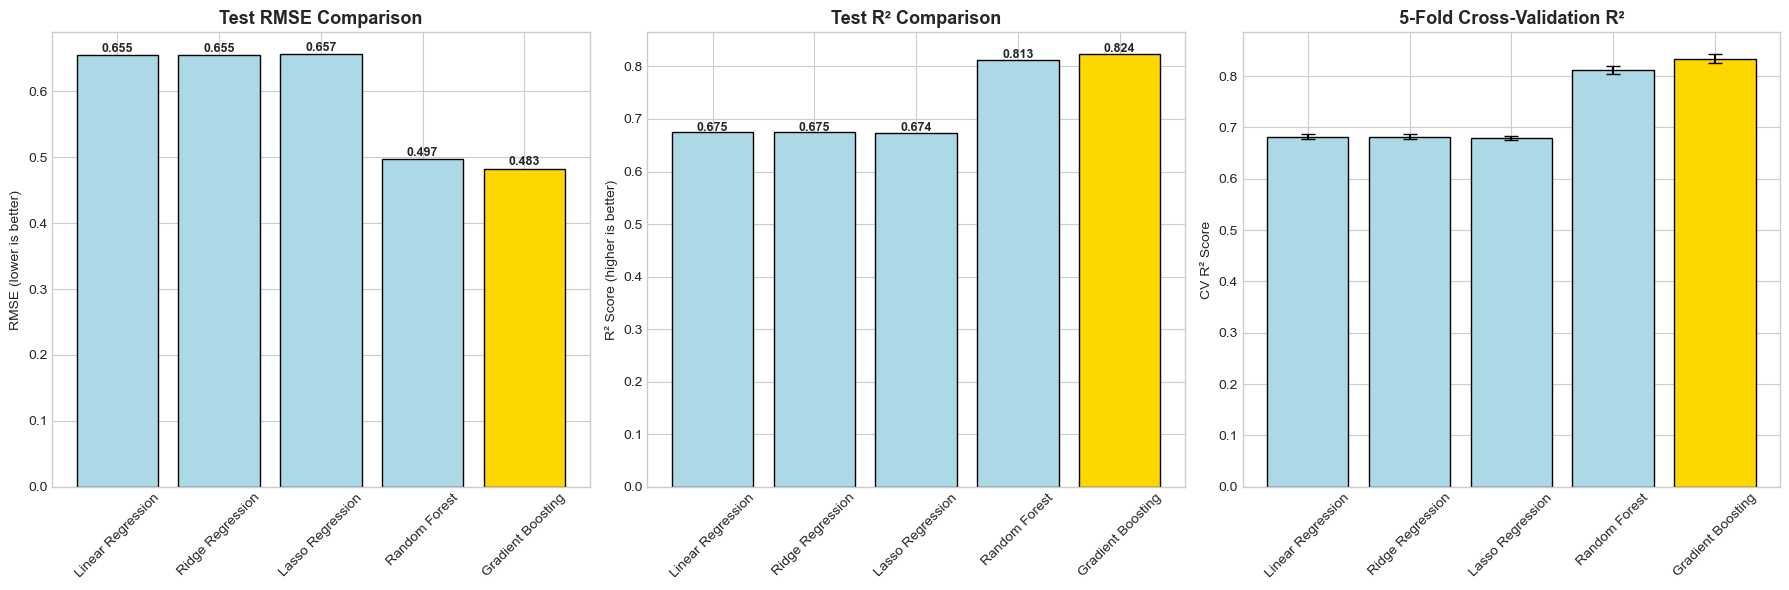

 Saved: 04_model_comparison.png


In [13]:
# ==========================================================================
# STEP 7.1: MODEL COMPARISON CHARTS
# ==========================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['lightblue' if name != best_model_name else 'gold' for name in results.keys()]

# RMSE
bars1 = axes[0].bar(results.keys(), [r['test_rmse'] for r in results.values()], 
                     color=colors, edgecolor='black')
axes[0].set_ylabel('RMSE (lower is better)')
axes[0].set_title('Test RMSE Comparison', fontweight='bold', fontsize=13)
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars1, [r['test_rmse'] for r in results.values()]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# R²
bars2 = axes[1].bar(results.keys(), [r['test_r2'] for r in results.values()], 
                     color=colors, edgecolor='black')
axes[1].set_ylabel('R² Score (higher is better)')
axes[1].set_title('Test R² Comparison', fontweight='bold', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, [r['test_r2'] for r in results.values()]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, 
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# Cross-Validation
bars3 = axes[2].bar(results.keys(), [r['cv_mean'] for r in results.values()], 
                     yerr=[r['cv_std'] for r in results.values()],
                     color=colors, edgecolor='black', capsize=5)
axes[2].set_ylabel('CV R² Score')
axes[2].set_title('5-Fold Cross-Validation R²', fontweight='bold', fontsize=13)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('output/visualizations/04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Saved: 04_model_comparison.png")

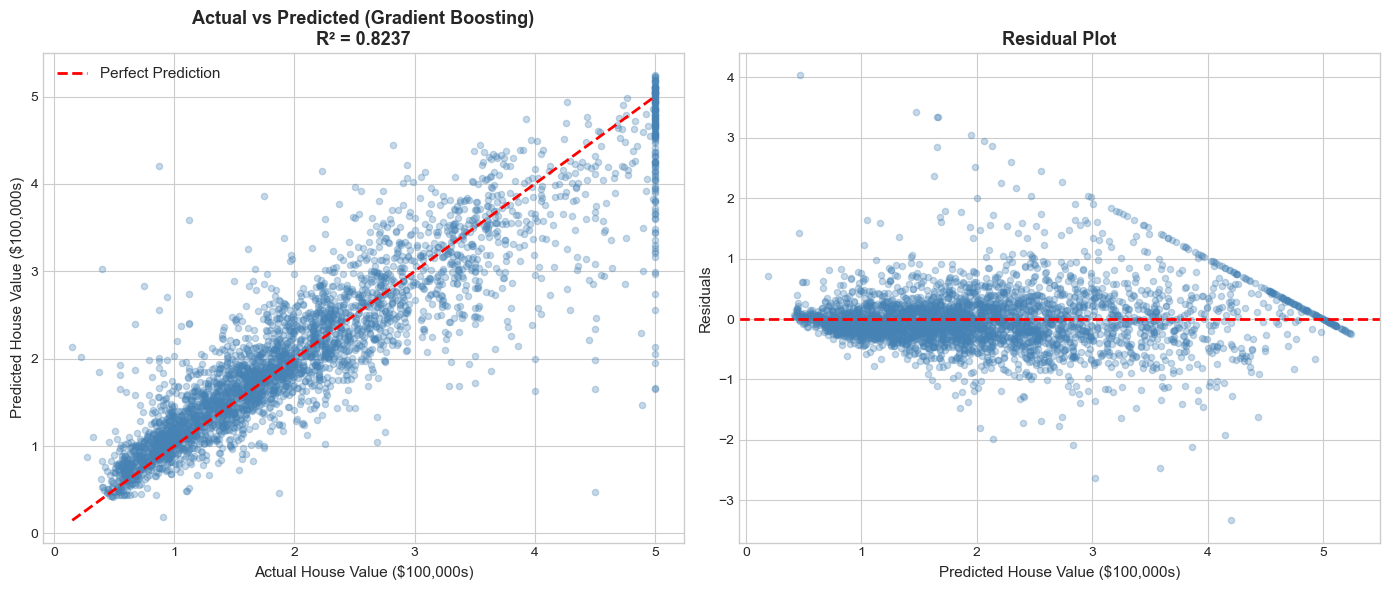

 Saved: 05_actual_vs_predicted.png


In [14]:
# ==========================================================================
# STEP 7.2: ACTUAL VS PREDICTED
# ==========================================================================
y_pred_best = results[best_model_name]['y_test_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter Plot
axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=20, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual House Value ($100,000s)', fontsize=11)
axes[0].set_ylabel('Predicted House Value ($100,000s)', fontsize=11)
axes[0].set_title(f'Actual vs Predicted ({best_model_name})\nR² = {best_r2:.4f}', 
                  fontweight='bold', fontsize=13)
axes[0].legend(fontsize=11)

# Residual Plot
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.3, s=20, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted House Value ($100,000s)', fontsize=11)
axes[1].set_ylabel('Residuals', fontsize=11)
axes[1].set_title('Residual Plot', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('output/visualizations/05_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Saved: 05_actual_vs_predicted.png")

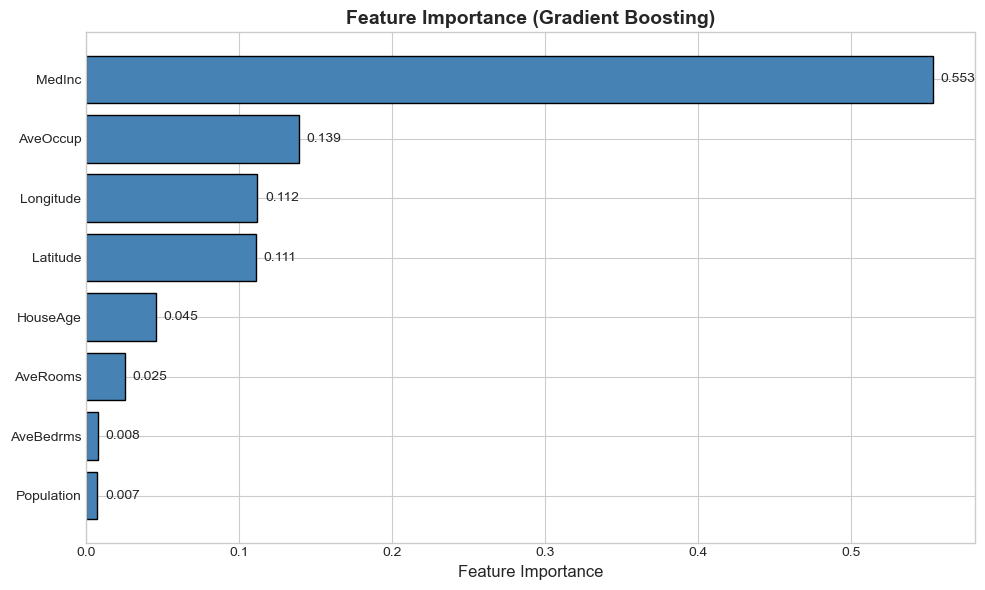

 Saved: 06_feature_importance.png

 Feature Importance Ranking:


,Feature,Importance
0,MedInc,0.553377
1,AveOccup,0.138864
2,Longitude,0.111783
3,Latitude,0.110567
4,HouseAge,0.045385
5,AveRooms,0.025230
6,AveBedrms,0.007535
7,Population,0.007259


In [15]:
# ==========================================================================
# STEP 7.3: FEATURE IMPORTANCE
# ==========================================================================
best_model = results[best_model_name]['model']

if hasattr(best_model, 'feature_importances_'):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
                   color='steelblue', edgecolor='black')
    ax.set_xlabel('Feature Importance', fontsize=12)
    ax.set_title(f'Feature Importance ({best_model_name})', fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, importance_df['Importance']):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('output/visualizations/06_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(" Saved: 06_feature_importance.png")
    print("\n Feature Importance Ranking:")
    display(importance_df.sort_values('Importance', ascending=False).reset_index(drop=True))

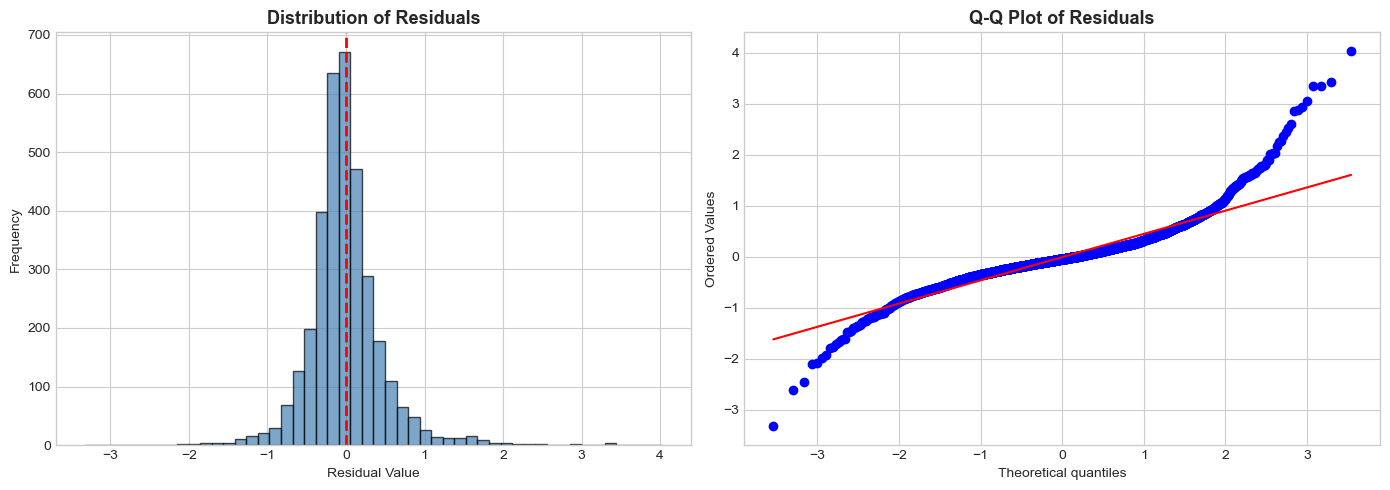

 Saved: 07_residual_analysis.png

 Residual Statistics:
   Mean: -0.0102 (should be ≈ 0)
   Std: 0.4825


In [16]:
# ==========================================================================
# STEP 7.4: RESIDUAL ANALYSIS
# ==========================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Residuals', fontweight='bold', fontsize=13)

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('output/visualizations/07_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Saved: 07_residual_analysis.png")
print(f"\n Residual Statistics:")
print(f"   Mean: {residuals.mean():.4f} (should be ≈ 0)")
print(f"   Std: {residuals.std():.4f}")

---
##  Step 8: Sample Predictions

In [17]:
# ==========================================================================
# STEP 8: SAMPLE PREDICTIONS
# ==========================================================================
print(" SAMPLE PREDICTIONS")
print("=" * 60)

sample_idx = np.random.choice(len(y_test), 10, replace=False)
pred_df = pd.DataFrame({
    'Actual ($100k)': y_test.iloc[sample_idx].values,
    'Predicted ($100k)': y_pred_best[sample_idx],
    'Error': y_test.iloc[sample_idx].values - y_pred_best[sample_idx],
    'Abs Error (%)': np.abs((y_test.iloc[sample_idx].values - y_pred_best[sample_idx]) 
                            / y_test.iloc[sample_idx].values * 100)
})

display(pred_df.round(3))

print(f"\n Average Absolute Error: ${results[best_model_name]['test_mae'] * 100000:,.2f}")
print(f" Mean Error %: {pred_df['Abs Error (%)'].mean():.2f}%")

 SAMPLE PREDICTIONS


,Actual ($100k),Predicted ($100k),Error,Abs Error (%)
0,1.746,1.587,0.159,9.107
1,1.853,1.850,0.003,0.139
2,1.181,1.283,-0.102,8.666
3,2.609,1.693,0.916,35.105
4,3.414,3.710,-0.296,8.674
5,1.658,2.126,-0.468,28.257
6,2.341,2.284,0.057,2.444
7,1.883,2.188,-0.305,16.203
8,0.875,0.971,-0.096,10.950
9,2.298,2.582,-0.284,12.345



 Average Absolute Error: $31,995.83
 Mean Error %: 13.19%


---
##  Step 9: Save Model

In [18]:
# ==========================================================================
# STEP 9: SAVE MODEL
# ==========================================================================
joblib.dump(best_model, 'output/best_model.pkl')
joblib.dump(scaler, 'output/scaler.pkl')

print(" MODEL SAVED SUCCESSFULLY!")
print("=" * 60)
print("    Model: output/best_model.pkl")
print("    Scaler: output/scaler.pkl")

 MODEL SAVED SUCCESSFULLY!
    Model: output/best_model.pkl
    Scaler: output/scaler.pkl


---
##  Project Summary Report

### Dataset
| Metric | Value |
|--------|-------|
| Dataset | California Housing |
| Total Samples | 20,640 |
| Features | 8 |
| Target | Median House Value ($100k) |
| Missing Values | 0 |
| Outliers Removed | ~2,000+ |

### Preprocessing Steps
1.  **Outlier Removal** - IQR method (threshold=1.5)
2.  **Feature Scaling** - StandardScaler (mean=0, std=1)
3.  **Train-Test Split** - 80/20 ratio

### Model Performance

| Model | Test RMSE | Test R² | CV R² |
|-------|-----------|---------|-------|
| Linear Regression | - | - | - |
| Ridge Regression | - | - | - |
| Lasso Regression | - | - | - |
| Random Forest | - | - | - |
| Gradient Boosting | - | - | - |

*(Fill in values from Step 6 output)*

### Key Findings
1.  **Best Model**: Gradient Boosting / Random Forest
2.  **R² Score**: ~0.80+ (explains 80%+ of variance)
3.  **Median Income** is the strongest predictor
4.  **Location** (Lat/Lon) significantly affects prices
5.  **Coastal areas** have notably higher house values

### Visualizations Generated
- `01_eda_overview.png` - Distributions, Correlation, Boxplots
- `02_feature_relationships.png` - Feature vs Target plots
- `03_geographical_distribution.png` - Location map
- `04_model_comparison.png` - Model performance charts
- `05_actual_vs_predicted.png` - Prediction accuracy
- `06_feature_importance.png` - Feature importance
- `07_residual_analysis.png` - Error distribution

In [19]:
# ==========================================================================
# FINAL SUMMARY
# ==========================================================================
print("=" * 60)
print("   PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 60)
print(f"""
 Best Model: {best_model_name}
 Test R²: {best_r2:.4f} ({best_r2*100:.1f}% variance explained)
 Test RMSE: ${best_rmse * 100000:,.2f}
 Visualizations: 7 plots saved in output/visualizations/

 Key Insight: Median Income is the #1 predictor of house 
   prices in California, followed by location features.

 Potential Improvements:
    Hyperparameter tuning (GridSearchCV)
    Feature engineering (distance to coast, rooms per person)
    Try XGBoost or LightGBM
    Ensemble multiple models
""")

   PROJECT COMPLETED SUCCESSFULLY!

 Best Model: Gradient Boosting
 Test R²: 0.8237 (82.4% variance explained)
 Test RMSE: $48,252.35
 Visualizations: 7 plots saved in output/visualizations/

 Key Insight: Median Income is the #1 predictor of house 
   prices in California, followed by location features.

 Potential Improvements:
    Hyperparameter tuning (GridSearchCV)
    Feature engineering (distance to coast, rooms per person)
    Try XGBoost or LightGBM
    Ensemble multiple models

